<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/04_EfficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Imports
2. Dataset paths and settings
3. Load datasets
4. Prefetch
5. Load pretrained model
6. Build classification model
7. Check model
8. Compile
9. Callbacks
10. Train
11. Learning curves
12. Initial test evaluation
13. Load best checkpoint
14. Final test evaluation
15. Classification report
16. Confusion matrix
17. Final results

Step 1 — Imports

In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

Step 2 — Dataset paths and settings

In [2]:
dataset_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes 500"

classes = [
    "kitchen",
    "bedroom",
    "bar",
    "livingroom",
    "warehouse"
]

image_size = (224, 224)
batch_size = 32

train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")
test_dir = os.path.join(dataset_dir, "test")

print("Dataset exists:", os.path.exists(dataset_dir))
print("Training directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(validation_dir))
print("Test directory exists:", os.path.exists(test_dir))

Dataset exists: True
Training directory exists: True
Validation directory exists: True
Test directory exists: True


Step 3 — Load the datasets

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 2500 files belonging to 5 classes.
Found 482 files belonging to 5 classes.
Found 484 files belonging to 5 classes.


In [4]:
#Verify
print("Class names:", train_ds.class_names)

print(
    "Training batches:",
    tf.data.experimental.cardinality(train_ds).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_ds).numpy()
)

print(
    "Test batches:",
    tf.data.experimental.cardinality(test_ds).numpy()
)

Class names: ['kitchen', 'bedroom', 'bar', 'livingroom', 'warehouse']
Training batches: 79
Validation batches: 16
Test batches: 16


Step 4 — Prefetch

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset prefetching configured.")

Dataset prefetching configured.


Step 5 — Load the pretrained EfficientNetB0

In [6]:
base_model = EfficientNetB0(
    include_top=False, # Removes the original ImageNet classification head
    weights="imagenet", #oads features learned from the ImageNet dataset.
    input_shape=(224, 224, 3)
)

base_model.trainable = False # Freezes the pretrained EfficientNetB0 weights

print("EfficientNetB0 loaded successfully.")
print("Base model trainable:", base_model.trainable) #initially freezes EfficientNetB0 so its pretrained features are not changed

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
EfficientNetB0 loaded successfully.
Base model trainable: False


Step 6 — Build the 5-class classification model

In [7]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False) #Extracts features using pretrained EfficientNetB0

x = tf.keras.layers.GlobalAveragePooling2D()(x) #Converts feature maps into a compact feature vector

x = tf.keras.layers.Dropout(0.2)(x) #Helps reduce overfitting

outputs = tf.keras.layers.Dense(
    5,                      #Produces predictions for our 5 selected classes
    activation="softmax"   #Converts outputs into class probabilities
)(x)

model = tf.keras.Model(inputs, outputs)

print("EfficientNetB0 model created successfully.")

EfficientNetB0 model created successfully.


Step 7 — Check the model

In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Step 8 — Compile the model

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(), #it expects integer class labels rather than one-hot encoded labels.
    metrics=["accuracy"]
)

In [10]:
print("Model compiled successfully.")

Model compiled successfully.


Step 9 — Set up training callbacks
1.   EarlyStopping — stops training if validation loss stops improving.
2.   ModelCheckpoint — saves the best version of the model.



In [11]:
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/efficientnetb0_newclasses.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks configured.")

Callbacks configured.


Step 10 — Train EfficientNetB0

In [12]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 733s 9s/step - accuracy: 0.7528 - loss: 0.7235 - val_accuracy: 0.8817 - val_loss: 0.3951
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.8876 - loss: 0.3401 - val_accuracy: 0.8983 - val_loss: 0.3240
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.9056 - loss: 0.2840 - val_accuracy: 0.9004 - val_loss: 0.3022
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.9108 - loss: 0.2488 - val_accuracy: 0.9046 - val_loss: 0.2860
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.9176 - loss: 0.2271 - val_accuracy: 0.9046 - val_loss: 0.2817
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.9176 - loss: 0.2135 - val_accuracy: 0.8963 - val_loss: 0.2808
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 0.9312 - loss: 0.1960 - val_accuracy: 0.9004 - val_loss: 0.2732
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.9308 - loss: 0.1874 - val_accuracy: 0.9046 - v

Step 11 - Plot the learning curves

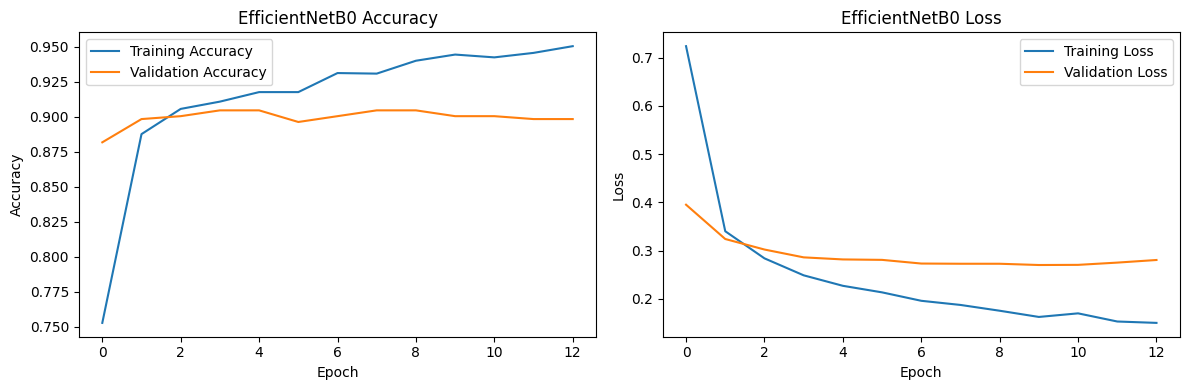

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Loss")
plt.legend()

plt.tight_layout()
plt.show()

Step 12 - Test evaluation

In [14]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 145s 9s/step - accuracy: 0.9070 - loss: 0.2456
Test Loss: 0.24563179910182953
Test Accuracy: 0.9070248007774353


Step 13 — Load the best checkpoint

In [15]:
# Load the best EfficientNetB0 model saved during training
best_model = tf.keras.models.load_model(checkpoint_path)

print("Best EfficientNetB0 model loaded successfully.")

Best EfficientNetB0 model loaded successfully.


Step 14 — Final test evaluation

In [16]:
test_loss, test_accuracy = best_model.evaluate(test_ds)

print("Best EfficientNetB0 Test Loss:", test_loss)
print("Best EfficientNetB0 Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9070 - loss: 0.2456
Best EfficientNetB0 Test Loss: 0.24563179910182953
Best EfficientNetB0 Test Accuracy: 0.9070248007774353


Step 15 - Classification Report

In [20]:
import numpy as np
from sklearn.metrics import classification_report

# Get the true labels from the test dataset
y_true = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

# Predictions from the best checkpoint
y_prob = best_model.predict(test_ds)

# Convert probabilities to predicted class numbers
y_pred = np.argmax(y_prob, axis=1)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

16/16 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step
              precision    recall  f1-score   support

     kitchen       0.96      0.92      0.94       111
     bedroom       0.83      0.86      0.85       100
         bar       0.98      0.97      0.97        91
  livingroom       0.80      0.82      0.81       106
   warehouse       1.00      1.00      1.00        76

    accuracy                           0.91       484
   macro avg       0.91      0.91      0.91       484
weighted avg       0.91      0.91      0.91       484



Step 16 — Confusion Matrix

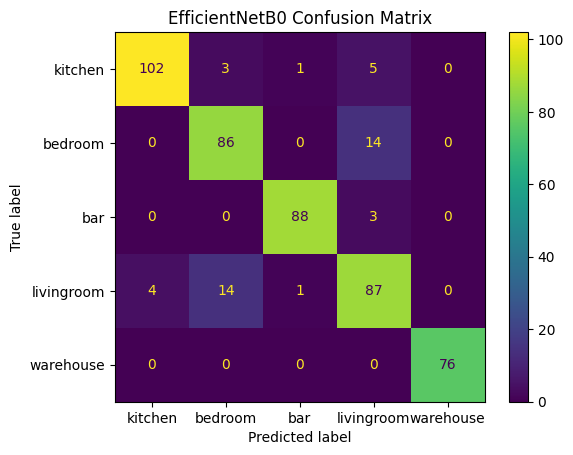

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()

plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

Step 17 — Final Results

In [22]:
correct_predictions = sum(
    np.array(y_true) == np.array(y_pred)
)

incorrect_predictions = sum(
    np.array(y_true) != np.array(y_pred)
)

print("EfficientNetB0 Final Results")
print("----------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {incorrect_predictions}")

EfficientNetB0 Final Results
----------------------------
Test Loss: 0.2456
Test Accuracy: 90.7025%
Correct Predictions: 439
Incorrect Predictions: 45
